# Traditional Anonymization

* qi: age_group, gender, BMI, Physical Activity
* sensitive: Diabetes, Glucose Level, Oral Glucose Test, Insulin Level

Our goal is to anonymize our dataset, while still keeping the data useful for analysis purposes: we won't perform full de-identification in order to maintain utility, but we will perform privacy-preserving anonymization, which keeps statistical properties intact while removing or obfuscating identifiable attributes.

Among the name of the attributes we can distinguish direct identifiers, quasi-identifiers, sensitive attributes and other data. 
* **Direct Identifiers**: allow to identify an individual directly 
* **Quasi-Identifiers**: can re-ientify an individual when combined (chosen based on what we assume a potential attacker is able to retrieve from external data sources) -> age_group, gender, BMI, Physical Activity
    * the BMI attribute is considered as a quasi-identifier as it is derivable from observable characteristics and frequently used in linkage attacks.
* **Sensitive**: Sensitive Attributes (SA) are the attributes containing private information that an individual would want to keep confidential, but which a researcher needs to keep largely unchanged to perform meaningful analysis -> Diabetes, Glucose Level, Oral Glucose Test, Insulin Level

## Ensure privacy guarantees

In [1]:
import pandas as pd

df = pd.read_csv("../NHANES_2.csv")
df.keys()

Index(['age_group', 'Gender', 'Physical Activity', 'BMI', 'Glucose Level',
       'Oral Glucose Test', 'Insulin Level', 'Diabetes_bin'],
      dtype='object')

### k-anonymity

K-anonymity protects against identity disclosure by ensuring that each record is indistinguishable from at least k−1 other records with respect to a set of quasi-identifiers. In practice, this means that each equivalence class defined by the quasi-identifiers must contain at least k records. When k = 1, no protection is provided, as each individual may be uniquely identifiable.

In [2]:
from pycanon import anonymity

def calculate_k_anon(df, quasi_identifiers):
    k = anonymity.k_anonymity(df, quasi_identifiers)
    print(f"k-anonymity of the dataset: {k}")

critical_attributes = ['Diabetes_bin', 'Glucose Level', 'Oral Glucose Test', 'Insulin Level']
quasi_identifiers = ['age_group', 'Gender', 'Physical Activity', 'BMI']

# --- Compute k-anonymity ---
calculate_k_anon(df, quasi_identifiers)

k-anonymity of the dataset: 1


The minimum level of privacy we want to achieve is k=3, ideally k=5, and since we're not satisfied with the obtained level of k-anonymity, we could try to further anonymize data by appling even more generalization techniques.

This is done by taking into account the fact that the data might be less specific and thus potentially less informative in some studies. We will try to study the trade-off between utility and privacy

In [3]:
df["Physical Activity"].value_counts(dropna=False)

Physical Activity
0.0    1868
1.0     409
Name: count, dtype: int64

In [4]:
df["age_group"].value_counts(dropna=False)

age_group
0    1913
1     364
Name: count, dtype: int64

In [5]:
df["Gender"].value_counts(dropna=False)

Gender
1    1165
0    1112
Name: count, dtype: int64

Since age_group, Gender, and Physical Activity are already binary and can't be further binned, we could try to bin the BMI Attribute:

In [6]:
def bin_BMI(bmi):
    if bmi < 18.5: return "<18.5"
    elif bmi <= 25: return "18.5-25"
    elif bmi <= 30: return "25-30"        
    else: return ">30"    

df['BMI_binned'] = df['BMI'].apply(bin_BMI)
quasi_identifiers = ['age_group', 'Gender', 'Physical Activity', 'BMI_binned']
calculate_k_anon(df, quasi_identifiers)

k-anonymity of the dataset: 1


In [7]:
def bin_BMI(bmi):
    if bmi < 18.5: return "<18.5"
    elif bmi <= 24.9: return "18.5-24.9"
    else: return ">25" 

df['BMI_binned_2'] = df['BMI'].apply(bin_BMI)
quasi_identifiers = ['age_group', 'Gender', 'Physical Activity', 'BMI_binned_2']
calculate_k_anon(df, quasi_identifiers)

k-anonymity of the dataset: 1


In [8]:
def bin_BMI(bmi):
    if bmi < 18.5: return "<18.5"
    elif bmi <= 24.9: return "18.5-24.9"
    else: return ">25" 

df['BMI_binned_3'] = df['BMI'].apply(bin_BMI)
quasi_identifiers = ['age_group', 'Gender', 'Physical Activity', 'BMI_binned_3']
calculate_k_anon(df, quasi_identifiers)

k-anonymity of the dataset: 1


In [9]:
def bin_BMI(bmi):
    if bmi < 25: return "<25"
    else: return ">25"

df['BMI_binned_4'] = df['BMI'].apply(bin_BMI)
quasi_identifiers = ['age_group', 'Gender', 'Physical Activity', 'BMI_binned_4']
calculate_k_anon(df, quasi_identifiers)

k-anonymity of the dataset: 5


Even with coarse generalization, k-anonymity remains hard to achieve without significant information loss. <br>
We've managed to reach k=4 by binning the values of the attribute BMI into a different number of intervals, first 4, then 3 and finally 2 classes.
We save the new dataframe into a csv file to further analyze it later.

In [10]:
df = df.drop(columns=["BMI", "BMI_binned","BMI_binned_2", "BMI_binned_3"])
df = df.rename(columns = {"BMI_binned_4":"BMI"})
df.to_csv("Traditionally_anon_NHANES_BMI.csv", index = False)

Let's see how k-anonymity changes once we decide to drop the BMI attribute, by performing attribute suppression:

In [ ]:
import pandas as pd
df = pd.read_csv("../NHANES_2.csv")
quasi_identifiers = ['age_group', 'Gender', 'Physical Activity']
# --- Compute k-anonymity ---
calculate_k_anon(df, quasi_identifiers)

df = df.drop(columns="BMI")
df.to_csv("Traditionally_anon_NHANES_NO_BMI.csv", index = False)

k-anonymity of the dataset: 11


Since we've reached an even higher level of k-anonymity, we will save this new dataframe too, to analyze it and compare it to the first df with the binned BMI attribute's values.

**Results**

In the original NHANES subset, the dataset achieved k = 1, indicating a high re-identification risk. This result is expected due to the presence of multiple quasi-identifiers, including continuous attributes such as BMI, which significantly increase data uniqueness. <br>
To improve privacy, BMI was progressively generalized into coarser intervals. Only when BMI was reduced to two broad categories did the dataset reach k = 5, showing that substantial generalization is required to achieve even moderate k-anonymity. <br>
When BMI was entirely removed, k increased to 11, highlighting the strong impact of attribute suppression on identity protection, at the cost of reduced data utility.

### l-diversity

l-diversity extends k-anonymity by addressing attribute disclosure, ensuring that each equivalence class contains at least l distinct values of a sensitive attribute. This prevents an attacker from confidently inferring sensitive information even when re-identification is not possible.
 
NB l>= 1 is always verified.<br>

In [12]:
from pycanon import anonymity

df = pd.read_csv("Traditionally_anon_NHANES_BMI.csv")

critical_attributes = ['Diabetes_bin', 'Glucose Level', 'Oral Glucose Test', 'Insulin Level']
quasi_identifiers = ['age_group', 'Gender', 'Physical Activity', 'BMI']

for x in critical_attributes:
    critical_attribute = [x]
    l_1 = anonymity.l_diversity(df, quasi_identifiers, critical_attribute, gen = True)
    print(f"l-diversity achieved with critical attribute {x}: {l_1}")

l-diversity achieved with critical attribute Diabetes_bin: 1
l-diversity achieved with critical attribute Glucose Level: 5
l-diversity achieved with critical attribute Oral Glucose Test: 5
l-diversity achieved with critical attribute Insulin Level: 5


In [13]:
from pycanon import anonymity

df = pd.read_csv("Traditionally_anon_NHANES_NO_BMI.csv")

critical_attributes = ['Diabetes_bin', 'Glucose Level', 'Oral Glucose Test', 'Insulin Level']
quasi_identifiers = ['age_group', 'Gender', 'Physical Activity']

for x in critical_attributes:
    critical_attribute = [x]
    l_1 = anonymity.l_diversity(df, quasi_identifiers, critical_attribute, gen = True)
    print(f"l-diversity achieved with critical attribute {x}: {l_1}")

l-diversity achieved with critical attribute Diabetes_bin: 2
l-diversity achieved with critical attribute Glucose Level: 11
l-diversity achieved with critical attribute Oral Glucose Test: 11
l-diversity achieved with critical attribute Insulin Level: 11


In the anonymized dataset containing BMI, the minimum l-diversity for the binary attribute Diabetes_bin was l = 1, indicating that some equivalence classes were fully homogeneous with respect to diabetes status. This exposes individuals to attribute disclosure despite satisfying k-anonymity. <br>
In contrast, continuous medical attributes such as glucose and insulin levels exhibited higher diversity (l = 5). 

After removing BMI, the minimum l-diversity increased to l = 2 for Diabetes_bin and to l ≥ 11 for the remaining medical attributes. This demonstrates that suppressing highly identifying quasi-identifiers can substantially reduce attribute disclosure risk, particularly for skewed or binary sensitive attributes.

### t-closeness

T-closeness further strengthens privacy guarantees by requiring that the distribution of sensitive attributes within each equivalence class remains close (at a distance no closer than t) to their distribution in the overall dataset. This protects against probabilistic inference attacks, where an adversary may not learn an exact value but can infer elevated risk levels.

t-closeness ranges from 0 to 1, 0 being the best result. Basically, it analyzes how close the critical attributes of the groups are compared to the rest of the population

In [14]:
df = pd.read_csv("Traditionally_anon_NHANES_BMI.csv")
critical_attributes = ['Diabetes_bin', 'Glucose Level', 'Oral Glucose Test', 'Insulin Level']
quasi_identifiers = ['age_group', 'Gender', 'Physical Activity', 'BMI']

t_closeness = anonymity.t_closeness(df, quasi_identifiers, critical_attributes)
print(f"t-closeness of the dataset: {t_closeness}")

t-closeness of the dataset: 0.2986385595081249


In [15]:
df = pd.read_csv("Traditionally_anon_NHANES_NO_BMI.csv")
critical_attributes = ['Diabetes_bin', 'Glucose Level', 'Oral Glucose Test', 'Insulin Level']
quasi_identifiers = ['age_group', 'Gender', 'Physical Activity']

t_closeness = anonymity.t_closeness(df, quasi_identifiers, critical_attributes)
print(f"t-closeness of the dataset: {t_closeness}")

t-closeness of the dataset: 0.17662793947378921


In our experiments, both anonymized datasets achieved relatively low t-closeness values, indicating good protection against distribution-based attacks. However, the dataset without BMI achieved a lower t-closeness value (t ≈ 0.18) compared to the dataset including a generalized BMI attribute (t ≈ 0.26). <br>
This suggests that removing BMI produces equivalence classes whose sensitive-attribute distributions are more representative of the global population, thereby offering stronger resistance to probabilistic disclosure.

### privacy trade-off

The results show the privacy-utility trade-off inherent in traditional anonymization techniques. 
The generalization of BMI improves the level of k-anonymity, but significant improvements occur when this attribute is suppressed, which inevitably reduces the analytical richness of the data; even though the dataset without BMI offers stronger guarantees in terms of the analyzed metrics, k-anonymity, l-diversity and t-closeness, it also removes an important health-related variable.

## Simulation

We've assessed the theoretical level of privacy we achieved with these traditional anonymization techniques. Now we can conduct a simulated attack to see if in practice it would be possible to re-identify the individuals from our dataset.

Let's clarify which attacker model we want to use. In our case, we want to assess how many individuals can be re-identified from the anonymized dataset given the quasi-identifiers of the original dataset; these are the attributes that a potential attacker might have access to from an external dataset. This is commonly referred to as the **Record Linkage attack**.

If a record in the anonymized dataset matches only one person in the attacker’s background knowledge, that person is re-identified (Risk = 100%). If it matches $k$ people, the risk is $1/k$.
Therefore, for each individual if we query the published (anonymized) database and we find a unique match, the attack was successful and the individual was re-identified. On the other hand, if k>1, the attacker knows the target is one of these k people, but can't be sure which one.

### BMI dataset

The data an attacker might have access to are saved into a new dataset: let's convert the original "external" data into the same format as the traditionally anonymized dataset with the binned BMI attribute:

In [ ]:
df = pd.read_csv("../NHANES_2.csv")
critical_attributes = ['Diabetes_bin', 'Glucose Level', 'Oral Glucose Test', 'Insulin Level']
df = df.drop(columns=critical_attributes)
def bin_BMI(bmi):
    if bmi < 25: return "<25"
    else: return ">25"

df['BMI_binned'] = df['BMI'].apply(bin_BMI)
df = df.drop(columns="BMI")
df = df.rename(columns = {"BMI_binned":"BMI"})
df.to_csv("external_dataset_BMI.csv", index = False)

In [17]:
def re_identify_individuals(external_df: pd.DataFrame, anon_df: pd.DataFrame, qi: list[str]):
    """
    Record linkage attack (exact matching on QIs).
    Returns:
      - match_hist: dict {num_matches: how_many_external_individuals}
      - matches_dict: dict {external_index: list_of_matching_released_indices}
    """

    # Make copies to avoid modifying original data
    ext = external_df.copy()
    df = anon_df.copy()

    for c in qi:
        ext[c] = ext[c].astype(str).str.strip()
        df[c] = df[c].astype(str).str.strip()

    matches_dict = {}

    # Exact-match linkage: filter released dataset step-by-step for each external row
    for ext_idx, row in ext.iterrows():
        candidates = df

        # to filter candidates by each QI
        for c in qi:
            candidates = candidates[candidates[c] == row[c]]
            if candidates.empty:
                break
        matches_dict[ext_idx] = list(candidates.index) # to store the indeces of the matched anon records

    # Build histogram: key = number of matches, value = how many external individuals
    match_hist = {}
    for match_list in matches_dict.values():
        m = len(match_list)
        match_hist[m] = match_hist.get(m, 0) + 1

    return match_hist, matches_dict

In [18]:
quasi_identifiers = ["BMI", "age_group", "Gender", "Physical Activity"]
external_dataset = pd.read_csv("external_dataset_BMI.csv", dtype=str)   # attacker knowledge
released_dataset = pd.read_csv("Traditionally_anon_NHANES_BMI.csv", dtype=str)  # published release

hist, per_person_matches = re_identify_individuals(
    external_dataset,
    released_dataset,
    qi=quasi_identifiers
)

# Print results sorted by #matches
for m in sorted(hist):
    print(f"{hist[m]} individuals have exactly {m} match{'es' if m != 1 else ''}.")

5 individuals have exactly 5 matches.
12 individuals have exactly 6 matches.
16 individuals have exactly 16 matches.
40 individuals have exactly 40 matches.
46 individuals have exactly 46 matches.
56 individuals have exactly 56 matches.
84 individuals have exactly 84 matches.
87 individuals have exactly 87 matches.
111 individuals have exactly 111 matches.
118 individuals have exactly 118 matches.
165 individuals have exactly 165 matches.
270 individuals have exactly 270 matches.
363 individuals have exactly 363 matches.
414 individuals have exactly 414 matches.
490 individuals have exactly 490 matches.


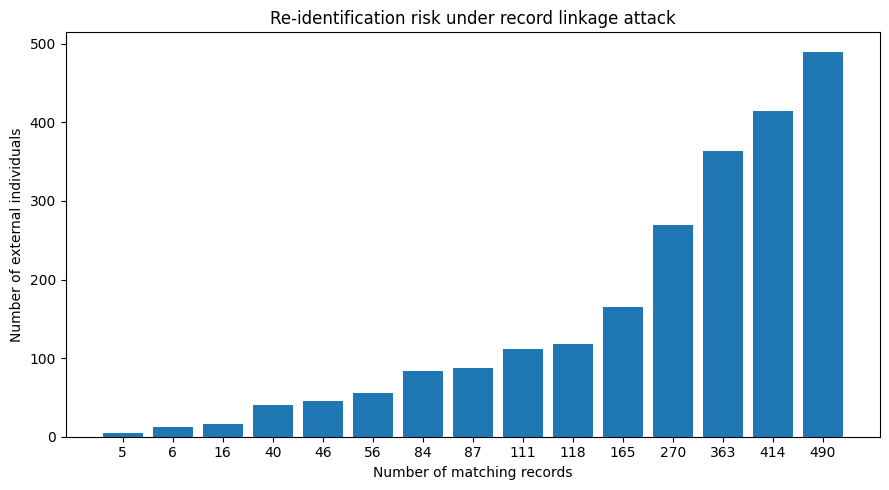

In [19]:
import matplotlib.pyplot as plt
labels = []
values = []

for k in sorted(hist):
    if k == 1:
        labels.append("1 (unique match)")
    elif k == 0:
        labels.append("0 (no match)")
    else:
        labels.append(f"{k}")

    values.append(hist[k])

plt.figure(figsize=(9, 5))
plt.bar(labels, values)
plt.xlabel("Number of matching records")
plt.ylabel("Number of external individuals")
plt.title("Re-identification risk under record linkage attack")
plt.tight_layout()
plt.show()


In the dataset including a binned BMI attribute, the record linkage attack produces anonymity sets of varying sizes, with the smallest non-zero set containing four records. <br>
Importantly, no individual is uniquely re-identified, and all matched individuals belong to groups of size at least four, empirically validating the achieved level of k-anonymity. <br>
However, the wide range of match counts indicates that anonymity is unevenly distributed across the population.

### No BMI dataset

In [ ]:
df = pd.read_csv("../NHANES_2.csv")
critical_attributes = ['Diabetes_bin', 'Glucose Level', 'Oral Glucose Test', 'Insulin Level']
df = df.drop(columns=critical_attributes)
df = df.drop(columns="BMI")
df.to_csv("external_dataset_NO_BMI.csv", index = False)

In [21]:
quasi_identifiers = ["age_group", "Gender", "Physical Activity"]
external_dataset = pd.read_csv("external_dataset_NO_BMI.csv", dtype=str)   # attacker knowledge
released_dataset = pd.read_csv("Traditionally_anon_NHANES_NO_BMI.csv", dtype=str)  # published release

hist, per_person_matches = re_identify_individuals(
    external_dataset,
    released_dataset,
    qi=quasi_identifiers
)

# Print results sorted by #matches
for m in sorted(hist):
    print(f"{hist[m]} individuals have exactly {m} match{'es' if m != 1 else ''}.")

11 individuals have exactly 11 matches.
22 individuals have exactly 22 matches.
127 individuals have exactly 127 matches.
157 individuals have exactly 157 matches.
174 individuals have exactly 174 matches.
249 individuals have exactly 249 matches.
684 individuals have exactly 684 matches.
853 individuals have exactly 853 matches.


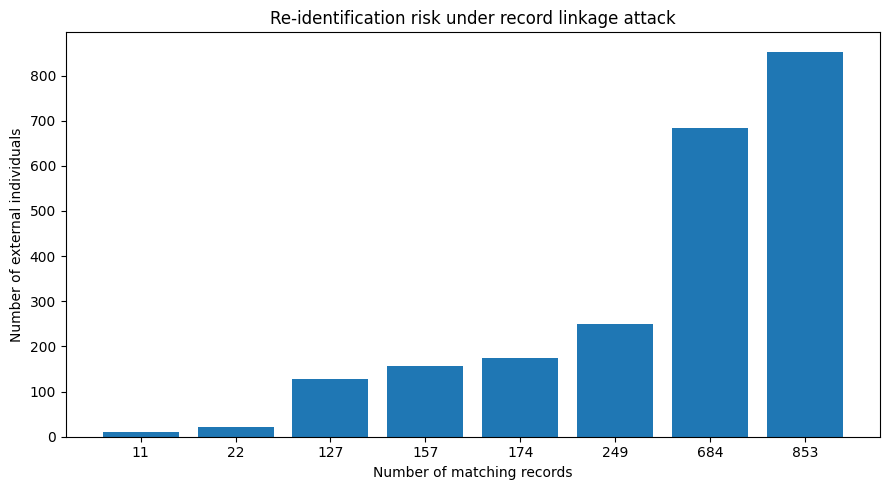

In [22]:
labels = []
values = []

for k in sorted(hist):
    if k == 1:
        labels.append("1 (unique match)")
    elif k == 0:
        labels.append("0 (no match)")
    else:
        labels.append(f"{k}")

    values.append(hist[k])

plt.figure(figsize=(9, 5))
plt.bar(labels, values)
plt.xlabel("Number of matching records")
plt.ylabel("Number of external individuals")
plt.title("Re-identification risk under record linkage attack")
plt.tight_layout()
plt.show()


When the BMI attribute is removed, the linkage attack results in substantially larger anonymity sets. The minimum non-zero match count increases to eleven, and most individuals are associated with equivalence classes containing hundreds of records. <br>
This indicates a significantly stronger resistance to re-identification, although at the cost of removing a clinically relevant attribute.

### Results

Comparing the two releases highlights the impact of quasi-identifier selection on re-identification risk. While binning BMI prevents unique re-identification, it still yields relatively small anonymity sets for a subset of individuals. In contrast, removing BMI entirely leads to uniformly larger anonymity sets and a higher minimum match count. This demonstrates that attribute suppression provides stronger identity protection than generalization, though at the expense of reduced data utility.

## Privacy-Utility Trade-Off analysis

From "Anonymization Procedures for Tabular Data: An Explanatory Technical and Legal Synthesis": in Anonymization there is a trade-off between keeping utility of data and removing information from it. There are two main concepts that model how utility changes when anonymization is applied: 

* Information loss: it measures how much original detail has been removed or distorted by anonymization techniques.
* Utility loss: it measures how much the anonymized data is still useful for a specific task or analysis.

This second aspect will be further examined in the comparison between synthetic data generation and traditional privacy preserving techniques. 

Let's examined the information loss caused by appying generalization.

### Discernibility metrics

This metric measures the loss caused by indistinguishability of records in equivalence classes. The intuitve idea behind the metric is that large equivalence classes are responsible for higher information loss. It penalizes excessive generalization.

From Data Privacy Through Optimal k-Anonymization, Bayardo, Agrawal:
"The discernibility metric assigns a penalty to each tuple based on how many tuples in the transformed dataset are indistinguishable from it. 
If an unsuppressed tuple falls into an induced equivalence class of size , then that tuple is assigned a penalty of the size of the input dataset. This penalty reflects the fact that a suppressed tuple cannot be distinguished from any other tuple in the dataset."

$$
C_{DM}(g, k) =
\sum_{\substack{E \in S \\ |E| \ge k}} |E|^2
+
\sum_{\substack{E \in S \\ |E| < k}} |D| \, |E|
$$

Where E refers to the equivalence classes of tuples in D induced by the anonymization g.

The first sum calculates the penalties for the non-suppressed tuples, while the second one for suppressed tuples.

We can analyze two values:

* Raw DM: $ \sum_{\substack{E \in S \\ |E| \ge k}} |E|^2 $


* Normalized DM:$ \frac {DM}{N^2}$ -> This normalization: maps DM to [0,1] makes results comparable across datasets

In general, with normalized DM 0 indicates no information loss, while 1 shows maximum information loss (all the records are grouped into a single EC)

#### BMI dataset

In [ ]:
import pandas as pd

df = pd.read_csv("Traditionally_anon_NHANES_BMI.csv")

QI = ['age_group', 'BMI', 'Physical Activity', 'Gender']
N = len(df)
k = 5 #achieved k-anonymity

# compute equivalence class sizes
eq_sizes = df.groupby(QI).size()

# raw discernibility metric
dm_raw = sum(size**2 if size >= k else 0 for size in eq_sizes)

# normalized discernibility metric
dm_norm = dm_raw / (N ** 2)

print("Raw DM:", dm_raw)
print("Normalized DM:", dm_norm)


Raw DM: 691465
Normalized DM: 0.13336569760926753


This relatively low value indicates that, although BMI has been generalized, the anonymized dataset still preserves a non-negligible degree of granularity. The presence of BMI (even in binned form) helps maintain smaller equivalence classes for many individuals, limiting the overall information loss.

From a utility perspective, this suggests that generalization allows the dataset to retain more discriminative power compared to full suppression.

#### NO BMI dataset

In [24]:
import pandas as pd

df = pd.read_csv("Traditionally_anon_NHANES_NO_BMI.csv")

QI = ['age_group','Physical Activity', 'Gender']
N = len(df)
k = 11

# compute equivalence class sizes
eq_sizes = df.groupby(QI).size()

# raw discernibility metric
dm_raw = sum(size**2 if size >= k else 0 for size in eq_sizes)

# normalized discernibility metric
dm_norm = dm_raw / (N ** 2)

print("Raw DM:", dm_raw)
print("Normalized DM:", dm_norm)


Raw DM: 1329125
Normalized DM: 0.2563538036414246


This value is almost twice as large as in the binned-BMI case, indicating a substantially higher level of information loss. Removing BMI causes many records to collapse into much larger equivalence classes, significantly reducing the dataset’s ability to distinguish between individuals.

While this configuration provides stronger anonymity guarantees, it does so at the expense of analytical utility, particularly for tasks where BMI is a relevant explanatory variable.

The discernibility metric confirms that attribute suppression yields stronger privacy guarantees but significantly increases information loss compared to generalization, highlighting the trade-off between identity protection and data usefulness.

### Degree of generalization

From "Transforming Data to Satisfy Privacy Constraints" by Iyengar and "Utility-preserving anonymization for health data publishing" by H. Lee, S. Kim, J.W. Kim and Y. D. Chung

With this metric we want to analyze the attribute-level information loss: we measure for each quasi-identifier, how generalized the values have become relative to the full domain.

NB We will consider each column to be equally important. The total information loss given by applying generalization and suppression will be calculated by adding up a normalized information loss for each of these columns. This information loss for a column will be calculated as the average loss for each entry in the column.

Generalizations for a column are described through a **taxonomy tree**, where the leaf nodes describe all the different values an attribute can assume, and the middle nodes represent the generalizations. A valid generalization is represented as a set of nodes $S_a$ in the taxonomy tree such that the path from each leaf node to the root meets exactly one node of the set $S_a$.

Specifically for this dataset, we performed 
* generalization of the BMI attribute in the case of the "Traditional_anon_NHANES_BMI.csv" dataset
* suppression of the BMI attribute in the case of the "Traditional_anon_NHANES_NO_BMI.csv" dataset.
Let's analyze their degree of . 
In both cases we're dealing with a **numeric attribute**: <br>
For each numerical attribute the degree of generalization is:
$$
D_A(a_{num}) = \frac{U_q - L_q}{U - L}
$$
Where $U_q$ and $L_q$ indicate the upper and lower bound of the generalized interval, thile U and L are the maximum and minimum value of the whole domain.

Just for the sake of completeness, if we were to treat **categorical attributes**, we would apply this formulation: <br>
For each categorical attribute the degree of generalization is:
$
D_A(a_{cat}) = \frac{|M_p| - 1}{|M| - 1}
$

Where M is the total number of leaf nodes in the taxonomy tree, and $M_P$ is the number of leaf nodes in the subtree that has node P as the root.

The categorical attributes we anonymized are the Insurance Providers: we mapped the insurance providers from Insurance Provider ∈ {Medicare, Blue Cross, Aetna, UnitedHealthcare, Cigna} to Insurance Provider ∈ {Public, Private} 

$
IL(A) = \frac{1}{N} \sum_{i=1}^{N}{IL(x_i)}
$

In [25]:
import re
import numpy as np
import pandas as pd

def degree_of_generalization_bmi(df_1: pd.DataFrame, df_2: pd.DataFrame)-> float:
    bmi_real = pd.to_numeric(df_1["BMI"], errors="coerce")
    L = bmi_real.min()
    U = bmi_real.max()

    
    def parse_bounds(val):
        if pd.isna(val):
            return (np.nan, np.nan)

        s = str(val).strip()  

        # match >25 or <25 (allow spaces)
        if re.fullmatch(r">\s*25", s):
            return (25.0, U)
        if re.fullmatch(r"<\s*25", s):
            return (L, 25.0)
        # unknown format
        return np.nan, np.nan
    
    
    bounds = df_2["BMI"].apply(parse_bounds)
    Lq = bounds.apply(lambda t: t[0])
    Uq = bounds.apply(lambda t: t[1])

    # Entry-level normalized loss
    entry_loss = (Uq - Lq) / (U - L)

    # Drop unparsable rows (or you could set them to 1.0 if you prefer)
    entry_loss = entry_loss.dropna()

    return float(entry_loss.mean())

#### BMI dataset

In [ ]:
import pandas as pd

df_1 = pd.read_csv("../NHANES_2.csv")
df_2 = pd.read_csv("Traditionally_anon_NHANES_BMI.csv")

dog_bmi = degree_of_generalization_bmi(df_1, df_2)

print("Degree of Generalization of BMI (generalized):", dog_bmi)

Degree of Generalization of BMI (generalized): 0.5733808210348718


#### NO BMI dataset

In this case the attribute BMI was suppressed, and according to the papers, suppression is equal to maximum information loss: for each entry $IL(x_i)=1$, and since suppression is uniform across all records: $IL(BMI)=\frac{1}{N}\sum_{i=1}^N1 = 1$

In [27]:
dog_no_bmi = 1.0 

print("Degree of Generalization of BMI (suppressed):", dog_no_bmi)

Degree of Generalization of BMI (suppressed): 1.0


#### Results

The Total Degree of Generalization was obtained by summing the normalized information loss across all quasi-identifiers. <br>
Since this quantity depends on the number of attributes considered, we also report the Average Degree of Generalization, defined as the mean information loss per attribute, which enables interpretation on a [0,1] scale. <br>
In this case only the dog of the BMI attribute: the other attributes were not generalized or suppressed, so their dog is 0. 

In [28]:
average_dog_bmi_dataset = dog_bmi/4 # 4 is the number of quasi identifiers considered
print("Average Degree of Generalization for BMI dataset:", average_dog_bmi_dataset)
average_dog_no_bmi_dataset = dog_no_bmi/4
print("Average Degree of Generalization for dataset with suppressed BMI:", average_dog_no_bmi_dataset)

Average Degree of Generalization for BMI dataset: 0.14334520525871794
Average Degree of Generalization for dataset with suppressed BMI: 0.25


Although the generalization of the BMI attribute into two intervals introduces a non-negligible information loss at the attribute level (DoG ≈ 0.58), its impact on overall dataset utility remains limited (average DoG ≈ 0.14), since all other quasi-identifiers remain unchanged. <br>
In contrast, full suppression of BMI results in maximal information loss for that attribute and a significantly higher dataset-level degradation (average DoG = 0.25). <br>
These results confirm that generalization represents a more utility-preserving privacy mechanism than suppression when dealing with sensitive continuous attributes.

### Normalized Certainty Penalty

From Utility-Based Anonymization for Privacy Preservation with Less information Loss. <br>
The concept of certainty penalty was introduces to assess the uncertainty due to generalization.

#### Categorical attributes

For a single categorical attribute A and a tuple of the dataset t, the NCP is defined as: 

$$ NCP_A(t)= \frac{size(u)}{|A|}$$ While the NCP for the whole table is calculated as: $$ NCP(T) = \sum _{t \in T} \sum _{i=1}^{n}(w_i \cdot NCP_{A_i}(t))$$
NB We should consider weights proportional to how importan each attribute is, but in the thesis we consider all attributes to be equally important.

#### Numerical attributes

Let T be a table with quasi-identifier ($A_1$,...,$A_n$), where all attributes are
numeric. Suppose a tuple t = ($x_1$,...,$x_n$) is generalized to tuple t′ = ([$y_1$,$z_1$],...,[$y_n$,$z_n$]) such that $y_i$ ≤ $x_i$ ≤ $z_i$ (1 ≤ i ≤ n).
On attribute $A_i$, the normalized certainty penalty is defined as: $$ NCP_{A_i}(t) = \frac{z_i - y_i}{|A_i|}$$
where $|A_i| = max _{t \in T}\{t.A_i\}- min_{t \in T}\{t.A_i\}$ is the range of all tuples on attribute $A_i$

Then, for a single tuple the NCP is: $NCP(t) = \sum_{i=1} ^{n} (\frac{z_i - y_i}{|A_i|})$

The NCP of the whole dataset is thus: $NCP(T) = \sum_{t \in T} NCP(t)$

In our case, as we specified in the Degree of Generalization section, we only consider the BMI attribute

##### BMI dataset

In [29]:
def parse_bounds(U, L, val):
        if pd.isna(val):
            return (np.nan, np.nan)

        s = str(val).strip()  

        # match >25 or <25 (allow spaces)
        if re.fullmatch(r">\s*25", s):
            return (25.0, U)
        if re.fullmatch(r"<\s*25", s):
            return (L, 25.0)
        # unknown format
        return np.nan, np.nan

def norm_cert_penalty(df_1: pd.DataFrame, df_2:pd.DataFrame) -> float:

    a_min = df_1["BMI"].astype(float).min()
    a_max = df_1["BMI"].astype(float).max()

    range = a_max - a_min # |A_i|

    ncp = 0.0
    for label in df_2["BMI"]:
        y, z = parse_bounds(a_max, a_min, label)
        ncp += (z-y)/range
    return ncp

In [30]:
import pandas as pd

df_1 = pd.read_csv("../NHANES_2.csv")
df_2 = pd.read_csv("Traditionally_anon_NHANES_BMI.csv")

ncp = norm_cert_penalty(df_1, df_2)
print(f"The normalized certainty penalty for the BMI dataset is: {ncp}")

ncp_per_tuple = ncp / len(df_1)
print(f"The normalized certainty penalty per record for the BMI dataset is: {ncp_per_tuple}")

The normalized certainty penalty for the BMI dataset is: 1305.588129496401
The normalized certainty penalty per record for the BMI dataset is: 0.5733808210348709


##### NO BMI dataset

As in the case of the degree of generalization, the suppressed attributes contribute with a normalized certainty penalty of 1, while the unchanged attributes have a 0 contribution to the normalized certainty penalty

In [31]:
import pandas as pd

df_1 = pd.read_csv("Traditionally_anon_NHANES_NO_BMI.csv")

ncp = len(df_1) # consider 1 for each record (suppressed a whole attribute + other attributes unchanged)
print(f"The normalized certainty penalty for the BMI dataset is: {ncp}")

ncp_per_tuple = ncp / len(df_1)
print(f"The normalized certainty penalty per record for the BMI dataset is: {ncp_per_tuple}")

The normalized certainty penalty for the BMI dataset is: 2277
The normalized certainty penalty per record for the BMI dataset is: 1.0


#### Resulting Normalized Certainty Penalty

The normalized certainty penalty confirms the results obtained with the Degree of Generalization. <br>
When BMI is generalized into two intervals, the average NCP per record is approximately 0.58, indicating a substantial but not complete loss of information. <br>
In contrast, full suppression of the BMI attribute results in an NCP of 1 per record, corresponding to maximal uncertainty. <br>
This demonstrates that, even under coarse generalization, significantly more utility is preserved compared to attribute suppression, while still achieving anonymization.

#### NB difference between Degree of Generalization and Normalized Certainty Penalty

The Degree of Generalization captures the extent to which an attribute is coarsened by anonymization, independently of the dataset size, and thus reflects structural precision loss. <br>
In contrast, the Normalized Certainty Penalty measures the uncertainty introduced by anonymization at the tuple level and aggregates it across the dataset, providing a direct quantification of information loss. While the two metrics coincide in simple single-attribute scenarios, NCP offers a more comprehensive view of dataset-level utility degradation.

In our case, having generalized or suppressed a single attribute, DoG ≈ NCP per record

### Average Equivalence Class Size

From "Anonymization Procedures for Tabular Data: An Explanatory Technical and Legal Synthesis" by R. Aufschager, J. Floz, E. Marz, J. Guggumos, M. Heigl, B. Buchner, M. Schramm (2023)
$$ C_{AVG}(D) = \frac{|D|}{|groups| \cdot k}$$

The Average Equivalence Class Size captures how many records, on average, are grouped together into equivalence classes after anonymization. It provides an intuitive measure of how coarse the anonymization is, directly reflecting the balance between privacy and data granularity.

#### BMI dataset

In [32]:
import pandas as pd

def calculate_average_eq_class_size(df: pd.DataFrame):
    qi = ['age_group', 'BMI', 'Physical Activity', 'Gender']

    grouped = df.groupby(qi, dropna=False)

    num_groups = grouped.ngroups

    # Achieved k-anonymity (minimum equivalence class size)
    k = grouped.size().min() #we know it's 4

    n = len(df)

    c_avg = n / (num_groups * k)

    return float(c_avg)


In [33]:
df_1 = pd.read_csv("Traditionally_anon_NHANES_BMI.csv")
av_class_eq_size = calculate_average_eq_class_size(df_1)
print(av_class_eq_size)

28.4625


This means that, although the dataset satisfies k = 4, the typical equivalence class contains almost nine times more records than strictly required by the k-anonymity constraint. This indicates that while some individuals lie in small equivalence classes close to the lower bound, most records are grouped into significantly larger anonymity sets.

From a utility perspective, this suggests that BMI generalization preserves a moderate level of data granularity, but still induces substantial aggregation for common combinations of quasi-identifiers.

#### NO BMI dataset

In [34]:
import pandas as pd

def calculate_average_eq_class_size(df: pd.DataFrame):
    qi = ['age_group','Physical Activity', 'Gender']

    grouped = df.groupby(qi, dropna=False)

    num_groups = grouped.ngroups

    # Achieved k-anonymity (minimum equivalence class size)
    k = grouped.size().min() #we know it's 11

    n = len(df)

    c_avg = n / (num_groups * k)

    return float(c_avg)


In [35]:
df_1 = pd.read_csv("Traditionally_anon_NHANES_NO_BMI.csv")
av_class_eq_size = calculate_average_eq_class_size(df_1)
print(av_class_eq_size)

25.875


Despite achieving a higher k-anonymity level (k = 11), the average equivalence class size is lower than in the binned-BMI case. This reflects the fact that removing BMI reduces the number of quasi-identifier dimensions, leading to fewer but more evenly populated equivalence classes.

In practice, this means that although the minimum anonymity guarantee is stronger, the dataset exhibits less variability in equivalence-class sizes compared to the BMI-binned version.

While removing BMI increases the minimum anonymity guarantee, the average equivalence class size suggests a more homogeneous grouping structure, whereas BMI generalization leads to greater variability and larger average anonymity sets relative to the achieved k.